# Нейронная сеть прямого распространения — Регрессия

**Нейронная сеть-регрессор** предсказывает непрерывную целевую переменную. Архитектура аналогична сети классификатора, но выходной нейрон имеет **линейную активацию**, а функция потерь — **MSE** (Mean Squared Error). Обучение ведётся методом backpropagation с оптимизатором Adam. Метрики качества: RMSE, MAE и R² (коэффициент детерминации).

**Датасет:** House Sales in King County — продажи домов в округе Кинг (США): 21 613 транзакций, 19 признаков (площадь, число комнат, год постройки и т.д.), целевая переменная — цена.

## 2. Используемые библиотеки

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42); np.random.seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 3. Описание и демонстрация датасета

In [17]:
df = pd.read_csv('./kc_house_data.csv')
print("Форма датасета:", df.shape)
print("\nПервые 10 строк:")
print(df.head(10).to_string())
print("\nОписательная статистика:")
print(df.describe().round(1).to_string())
print("\nЦелевая переменная (price):")
print(f"  Min: ${df['price'].min():,.0f}")
print(f"  Max: ${df['price'].max():,.0f}")
print(f"  Mean: ${df['price'].mean():,.0f}")
print(f"  Median: ${df['price'].median():,.0f}")

Форма датасета: (21613, 21)

Первые 10 строк:
           id             date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  zipcode      lat     long  sqft_living15  sqft_lot15
0  7129300520  20141013T000000   221900.0         3       1.00         1180      5650     1.0           0     0          3      7        1180              0      1955             0    98178  47.5112 -122.257           1340        5650
1  6414100192  20141209T000000   538000.0         3       2.25         2570      7242     2.0           0     0          3      7        2170            400      1951          1991    98125  47.7210 -122.319           1690        7639
2  5631500400  20150225T000000   180000.0         2       1.00          770     10000     1.0           0     0          3      6         770              0      1933             0    98028  47.7379 -122.233           2720        8062
3  2487200875 

## 4. Предварительная обработка

In [18]:
# Удалить id и дату; извлечь год/месяц из даты
df['date'] = pd.to_datetime(df['date'])
df['sale_year']  = df['date'].dt.year
df['sale_month'] = df['date'].dt.month
df = df.drop(['id','date'], axis=1)

# Логарифмирование целевой переменной (скошенное распределение)
df['log_price'] = np.log1p(df['price'])

print("Пропущенные значения:", df.isnull().sum().sum())

feature_cols = [c for c in df.columns if c not in ['price','log_price']]
X = df[feature_cols].values
y = df['price'].values
y_log = df['log_price'].values

X_train, X_test, y_train, y_test, yl_train, yl_test = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nПризнаки ({len(feature_cols)}): {feature_cols}")
print(f"Train: {X_train_sc.shape},  Test: {X_test_sc.shape}")

Пропущенные значения: 0

Признаки (20): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month']
Train: (17290, 20),  Test: (4323, 20)


## 5. Тепловая карта корреляций

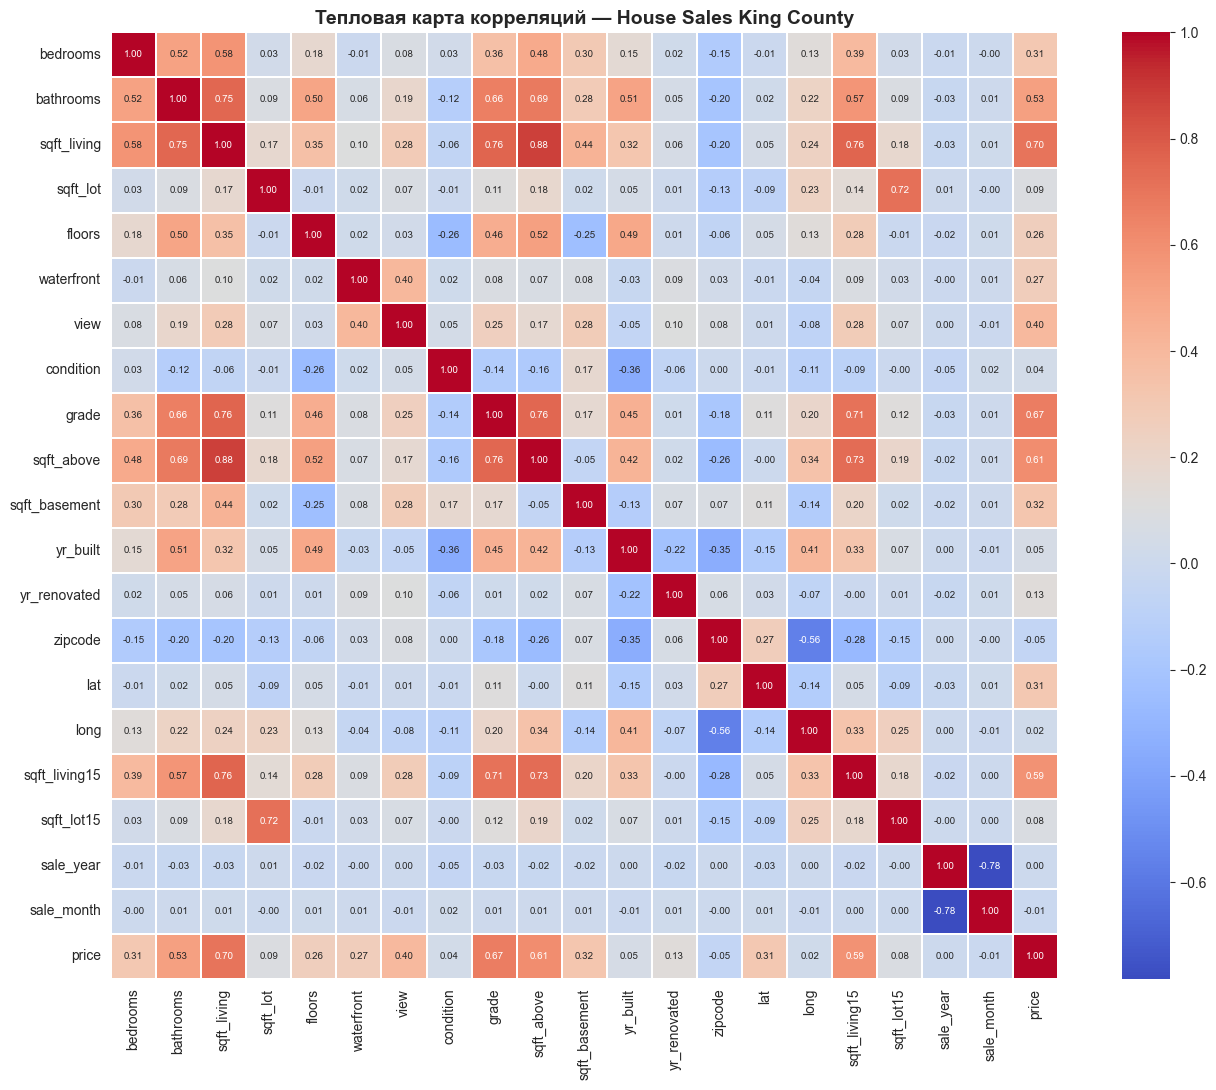

Топ-10 признаков по корреляции с price:
sqft_living      0.702
grade            0.667
sqft_above       0.606
sqft_living15    0.585
bathrooms        0.525
view             0.397
sqft_basement    0.324
bedrooms         0.308
lat              0.307
waterfront       0.266


In [19]:
plt.figure(figsize=(14, 11))
corr = df[feature_cols + ['price']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.3, annot_kws={'size': 7})
plt.title('Тепловая карта корреляций — House Sales King County', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Топ-10 признаков по корреляции с ценой
top10 = corr['price'].abs().sort_values(ascending=False)[1:11]
print("Топ-10 признаков по корреляции с price:")
print(top10.round(3).to_string())

## 6. Обучение нейронной сети

In [20]:
model = keras.Sequential([
    layers.Input(shape=(len(feature_cols),)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
], name='HousePrice_NN')

model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])
model.summary()

Model: "HousePrice_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,177 (196.00 KB)

 Trainable params: 49,409 (193.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [21]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True, monitor='val_loss'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, verbose=0)
]
# Обучаем предсказывать log(price) — стабильнее
history = model.fit(X_train_sc, yl_train, epochs=300, batch_size=64,
                    validation_split=0.2, callbacks=callbacks, verbose=1)

Epoch 1/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.0143 - mae: 2.0200 - val_loss: 3.7516 - val_mae: 1.6993 - learning_rate: 0.0010
Epoch 2/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1697 - mae: 0.8594 - val_loss: 0.7552 - val_mae: 0.7146 - learning_rate: 0.0010
Epoch 3/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9844 - mae: 0.7882 - val_loss: 0.5450 - val_mae: 0.6000 - learning_rate: 0.0010
Epoch 4/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8629 - mae: 0.7387 - val_loss: 0.5797 - val_mae: 0.6260 - learning_rate: 0.0010
Epoch 5/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7647 - mae: 0.6929 - val_loss: 0.6741 - val_mae: 0.6774 - learning_rate: 0.0010
Epoch 6/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7075 - mae: 0.6678 - val_loss: 0.5734 - val_mae: 0.6294 - learning_rate: 0.0010
Epoch 7/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6498 - mae: 0.6416 - val_loss: 0.6882 - val_mae: 0.7031 - learning_rate: 0.001

## 7. Прогнозы модели

In [22]:
y_log_pred = model.predict(X_test_sc, verbose=0).ravel()
y_pred     = np.expm1(y_log_pred)   # обратное преобразование log1p

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== Метрики качества (в оригинальных $) ===")
print(f"RMSE: {rmse:,.0f}")
print(f"MAE:  {mae:,.0f}")
print(f"R²:   {r2:.4f}")

results_df = pd.DataFrame({'Истинная_цена': y_test.astype(int),
                            'Предсказанная': y_pred.round(0).astype(int),
                            'Ошибка_': (y_pred - y_test).round(0).astype(int)})
print("\nПервые 15 прогнозов:")
print(results_df.head(15).to_string())

=== Метрики качества (в оригинальных $) ===
RMSE: 135,640
MAE:  72,483
R²:   0.8783

Первые 15 прогнозов:
    Истинная_цена  Предсказанная  Ошибка_
0          365000         342231   -22769
1          865000         888884    23884
2         1038000        1083647    45647
3         1490000        2101882   611882
4          711000         732270    21270
5          211000         243661    32661
6          790000         745210   -44790
7          680000         573034  -106966
8          384500         417061    32561
9          605000         479957  -125043
10         638000         704148    66148
11         385000         404853    19853
12         175000         237703    62703
13         365000         373744     8744
14         160000         138742   -21258


## 8. Графики результатов

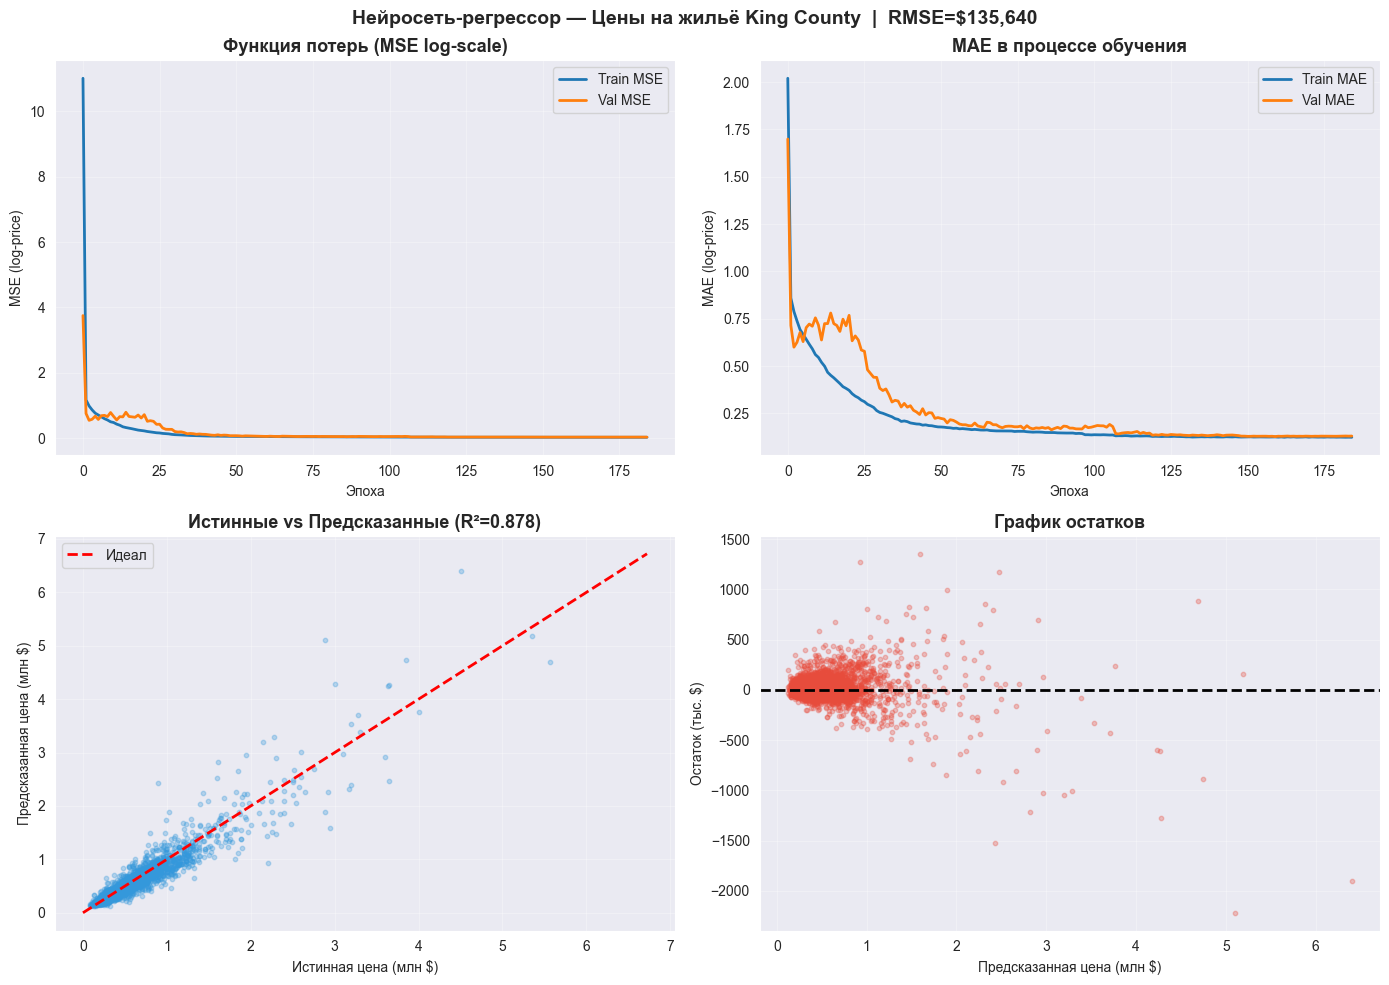

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0,0].plot(history.history['loss'],     label='Train MSE', linewidth=2)
axes[0,0].plot(history.history['val_loss'], label='Val MSE',   linewidth=2)
axes[0,0].set_title('Функция потерь (MSE log-scale)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Эпоха'); axes[0,0].set_ylabel('MSE (log-price)')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# MAE
axes[0,1].plot(history.history['mae'],     label='Train MAE', linewidth=2)
axes[0,1].plot(history.history['val_mae'], label='Val MAE',   linewidth=2)
axes[0,1].set_title('MAE в процессе обучения', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Эпоха'); axes[0,1].set_ylabel('MAE (log-price)')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Предсказанные vs Истинные
axes[1,0].scatter(y_test/1e6, y_pred/1e6, alpha=0.3, s=10, c='#3498DB')
lims = [0, max(y_test.max(), y_pred.max())/1e6 * 1.05]
axes[1,0].plot(lims, lims, 'r--', linewidth=2, label='Идеал')
axes[1,0].set_title(f'Истинные vs Предсказанные (R²={r2:.3f})', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Истинная цена (млн $)'); axes[1,0].set_ylabel('Предсказанная цена (млн $)')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# Остатки
residuals = y_test - y_pred
axes[1,1].scatter(y_pred/1e6, residuals/1e3, alpha=0.3, s=10, c='#E74C3C')
axes[1,1].axhline(0, color='black', linestyle='--', linewidth=2)
axes[1,1].set_title('График остатков', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Предсказанная цена (млн $)'); axes[1,1].set_ylabel('Остаток (тыс. $)')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Нейросеть-регрессор — Цены на жильё King County  |  RMSE=${rmse:,.0f}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

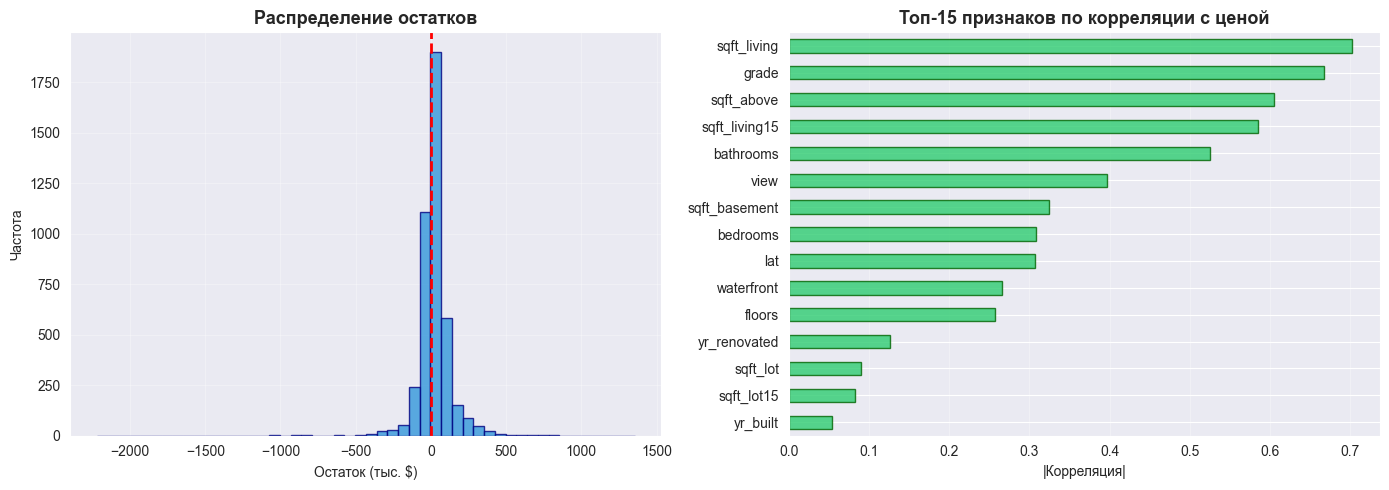

In [24]:
# Распределение остатков + важность признаков (по корреляции)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(residuals/1e3).hist(bins=50, ax=axes[0], color='#3498DB', edgecolor='navy', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Распределение остатков', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Остаток (тыс. $)'); axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

corr_price = df[feature_cols + ['price']].corr()['price'].abs().sort_values(ascending=False)[1:]
corr_price.head(15).plot(kind='barh', ax=axes[1], color='#2ECC71', edgecolor='darkgreen', alpha=0.8)
axes[1].set_title('Топ-15 признаков по корреляции с ценой', fontsize=13, fontweight='bold')
axes[1].set_xlabel('|Корреляция|'); axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()